In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import PyPizza
from scipy.stats import rankdata

from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
import matplotlib.patheffects as patheffects
import matplotlib.colors as mc

import colorsys

In [63]:
raw_prva_liga_24_25_df = pd.read_excel("../data/serbia_prva_liga_24_25.xlsx")
# raw_prva_liga_25_26_df = pd.read_excel("../data/serbia_prva_liga_25_26.xlsx")

# raw_prva_liga_25_26_df["original_position_value"] = raw_prva_liga_25_26_df['Position']
# raw_prva_liga_25_26_df['Position'] = raw_prva_liga_25_26_df["Position"].str.split(",").str[0].str.strip()
# raw_prva_liga_25_26_df['League'] = "Serbia Prva Liga 2025-26"
# raw_prva_liga_24_25_df["original_position_value"] = raw_prva_liga_24_25_df['Position']
# raw_prva_liga_24_25_df['Position'] = raw_prva_liga_24_25_df["Position"].str.split(",").str[0].str.strip()
raw_prva_liga_24_25_df['League'] = "Serbia Prva Liga 2024-25"

In [64]:
league_map = {

# ALBANIA
"Albania Superiore League": ("Kategoria Superiore", "Albania"),

# ARGENTINA
"Argentina Primera Division": ("Liga Profesional de Fútbol", "Argentina"),

# AUSTRALIA
"Australia A-League": ("A-League Men", "Australia"),

# AUSTRIA
"Austria Bundesliga": ("Austrian Bundesliga", "Austria"),

# BELGIUM
"Belgium First Division A": ("Belgian Pro League", "Belgium"),
"Belgium First Division B": ("Challenger Pro League", "Belgium"),

# BOLIVIA
"Bolivia Primera Division": ("División Profesional", "Bolivia"),

# BOSNIA
"Bosnia Premijer Liga": ("Premijer Liga", "Bosnia and Herzegovina"),

# BRAZIL
"Brazil Serie A": ("Campeonato Brasileiro Série A", "Brazil"),
"Brazil Serie B": ("Campeonato Brasileiro Série B", "Brazil"),

# BULGARIA
"Bulgaria First League": ("First Professional Football League", "Bulgaria"),

# CANADA
"Canada Premier League": ("Canadian Premier League", "Canada"),

# CHILE
"Chile Primera Division": ("Campeonato Nacional", "Chile"),

# CHINA
"China Super League": ("Chinese Super League", "China"),

# COLOMBIA
"Colombia Primera A": ("Categoría Primera A", "Colombia"),

# COSTA RICA
"Costa Rica Primera Division": ("Liga FPD", "Costa Rica"),

# CROATIA
"Croatia 1.HNL": ("SuperSport HNL", "Croatia"),

# CYPRUS
"Cyprus First Division": ("Cypriot First Division", "Cyprus"),

# CZECHIA
"Czech Fortuna Liga": ("Chance Liga", "Czech Republic"),

# DENMARK
"Denmark Superliga": ("Danish Superliga", "Denmark"),
"Denmark 1st Division": ("Danish 1st Division", "Denmark"),

# ECUADOR
"Ecuador Serie A": ("LigaPro Serie A", "Ecuador"),

# EGYPT
"Egypt Premier League": ("Egyptian Premier League", "Egypt"),

# ENGLAND
"England Premier League": ("Premier League", "England"),
"England Championship": ("EFL Championship", "England"),
"England League One": ("EFL League One", "England"),
"England League Two": ("EFL League Two", "England"),
"England National League": ("National League", "England"),
"England National League North South": ("National League North/South", "England"),

# ESTONIA
"Estonia Meistriliiga": ("Meistriliiga", "Estonia"),

# FINLAND
"Finland Veikkausliiga": ("Veikkausliiga", "Finland"),

# FRANCE
"France Ligue 1": ("Ligue 1", "France"),
"France Ligue 2": ("Ligue 2", "France"),
"France Championnat National": ("Championnat National", "France"),

# GEORGIA
"Georgia Erovnuli Liga": ("Erovnuli Liga", "Georgia"),

# GERMANY
"Germany Bundesliga": ("Bundesliga", "Germany"),
"Germany 2. Bundesliga": ("2. Bundesliga", "Germany"),
"Germany 3. Liga": ("3. Liga", "Germany"),

# GREECE
"Greece Super League": ("Super League Greece", "Greece"),

# HUNGARY
"Hungary NB1": ("Nemzeti Bajnokság I", "Hungary"),

# INDONESIA
"Indonesia Liga 1": ("Liga 1", "Indonesia"),

# IRELAND
"Ireland Premier Division": ("League of Ireland Premier Division", "Ireland"),
"Ireland First Division": ("League of Ireland First Division", "Ireland"),

# ISRAEL
"Israel Ligat Ha'Al": ("Ligat Ha'Al", "Israel"),

# ITALY
"Italy Serie A": ("Serie A", "Italy"),
"Italy Serie B": ("Serie B", "Italy"),
"Italy Campionato Primavera 1": ("Campionato Primavera 1", "Italy"),

# JAPAN
"Japan J1-League": ("J1 League", "Japan"),
"Japan J2-League": ("J2 League", "Japan"),

# KAZAKHSTAN
"Kazakhstan Premier League": ("Kazakhstan Premier League", "Kazakhstan"),

# KOREA
"Korea K-League 1": ("K League 1", "South Korea"),
"Korea K-League 2": ("K League 2", "South Korea"),

# LATVIA
"Latvia Virsliga": ("Virslīga", "Latvia"),

# MALAYSIA
"Malaysia Super League": ("Malaysia Super League", "Malaysia"),

# MEXICO
"Mexico Liga MX": ("Liga MX", "Mexico"),
"Mexico Liga de Expansion": ("Liga de Expansión MX", "Mexico"),

# MOROCCO
"Morocco Botola Pro": ("Botola Pro", "Morocco"),

# NETHERLANDS
"Netherlands Eredivisie": ("Eredivisie", "Netherlands"),
"Netherlands Eerste Divisie": ("Eerste Divisie", "Netherlands"),

# NORTHERN IRELAND
"Northern Ireland Premiership": ("NIFL Premiership", "Northern Ireland"),

# NORWAY
"Norway Eliteserien": ("Eliteserien", "Norway"),
"Norway First Division": ("OBOS-ligaen", "Norway"),

# PARAGUAY
"Paraguay Primera Division": ("División Profesional", "Paraguay"),

# PERU
"Peru Primera Division": ("Liga 1", "Peru"),

# POLAND
"Poland Ekstraklasa": ("Ekstraklasa", "Poland"),
"Poland 1 Liga": ("I liga", "Poland"),

# PORTUGAL
"Portugal Primeira Liga": ("Primeira Liga", "Portugal"),
"Portugal Segunda Liga": ("Liga Portugal 2", "Portugal"),

# ROMANIA
"Romania SuperLiga": ("SuperLiga", "Romania"),

# RUSSIA
"Russia Premier League": ("Russian Premier League", "Russia"),

# SCOTLAND
"Scotland Premiership": ("Scottish Premiership", "Scotland"),
"Scotland Championship": ("Scottish Championship", "Scotland"),
"Scotland League One": ("Scottish League One", "Scotland"),
"Scotland League Two": ("Scottish League Two", "Scotland"),

# SERBIA
"Serbia Super Liga": ("Serbian Super Liga", "Serbia"),
"Serbia Prva Liga": ("Serbian Prva Liga", "Serbia"), 

# SLOVAKIA
"Slovakia Super Liga": ("Niké Liga", "Slovakia"),

# SLOVENIA
"Slovenia Prva Liga": ("PrvaLiga", "Slovenia"),

# SOUTH AFRICA
"South Africa PSL": ("Premier Soccer League", "South Africa"),

# SPAIN
"Spain La Liga": ("La Liga", "Spain"),
"Spain Segunda": ("LaLiga Hypermotion", "Spain"),
"Spain Primera Division RFEF": ("Primera Federación", "Spain"),

# SWEDEN
"Sweden Allsvenskan": ("Allsvenskan", "Sweden"),

# SWITZERLAND
"Switzerland Super League": ("Swiss Super League", "Switzerland"),
"Switzerland Challenge League": ("Swiss Challenge League", "Switzerland"),

# TURKEY
"Turkey Super Lig": ("Süper Lig", "Turkey"),

# UKRAINE
"Ukraine Premier League": ("Ukrainian Premier League", "Ukraine"),

# URUGUAY
"Uruguay Primera Division": ("Primera División", "Uruguay"),

# USA
"USA MLS": ("Major League Soccer", "USA"),
"USA MLS Next Pro": ("MLS Next Pro", "USA"),
"USA USL Championship": ("USL Championship", "USA"),

# UZBEKISTAN
"Uzbekistan Super League": ("Uzbek Super League", "Uzbekistan"),

# VENEZUELA
"Venezuela Primera Division": ("Primera División", "Venezuela"),
}

wyscout_df = pd.read_csv("../data/Wyscout_League_Export.csv")

df = pd.concat(
    [wyscout_df, raw_prva_liga_24_25_df],
    ignore_index=True
)

df.columns = (
    df.columns
    .str.lower()
    .str.replace(",", "")
    .str.replace(" ", "_")
)

df["league_base"] = df["league"].str.replace(r"\s\d{4}(-\d{2})?$", "", regex=True)
df["league_name"] = df["league_base"].map(lambda x: league_map.get(x, (None, None))[0])
df["league_country"] = df["league_base"].map(lambda x: league_map.get(x, (None, None))[1])
df["season"] = df["league"].str.extract(r"(\d{4}(?:-\d{2})?)$")

df["original_position_value"] = df['position']
df['position'] = df["position"].str.split(",").str[0].str.strip()

def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator

df["xa_per_100_passes"] = (
    safe_divide(df["xa_per_90"], df["passes_per_90"]) * 100
)

df["xa_per_cross"] = safe_divide(
    df["xa_per_90"],
    df["crosses_per_90"],
)

df["crosses_share_of_passes_%"] = (
    safe_divide(df["crosses_per_90"], df["passes_per_90"]) * 100
)

df["key_passes_per_100_passes"] = (
    df["key_passes_per_90"] / df["passes_per_90"].replace(0, np.nan)
) * 100

df["non_penalty_xg"] = df["xg"] - (df["penalties_taken"] * 0.76)
df["non_penalty_xg"] = df["non_penalty_xg"].clip(lower=0)

df["non_penalty_xg_per_90"] = (
    safe_divide(df["non_penalty_xg"], df["minutes_played"]) * 90
)

super_liga_24_25_df = df[df["league"] == "Serbia Super Liga 2024-25"].copy()
super_liga_25_26_df = df[df["league"] == "Serbia Super Liga 2025-26"].copy()
prva_liga_24_25_df = df[df["league"] == "Serbia Prva Liga 2024-25"].copy()
prva_liga_25_26_df = df[df["league"] == "Serbia Prva Liga 2025-26"].copy()

In [ ]:
# prva_liga_25_26_df.columns = (
#     prva_liga_25_26_df.columns
#     .str.lower()
#     .str.replace(",", "")
#     .str.replace(" ", "_")
# )
# prva_liga_24_25_df.columns = (
#     prva_liga_24_25_df.columns
#     .str.lower()
#     .str.replace(",", "")
#     .str.replace(" ", "_")
# )

# prva_liga_25_26_df['position'].value_counts()

In [216]:
prva_liga_25_26_df[
    # (prva_liga_25_26_df["team"] == "Jedinstvo Ub")
     (prva_liga_25_26_df["position"].isin(["RCB", "LCB"]))
    & (prva_liga_25_26_df["minutes_played"] >= 100)
][["player", "team", "defensive_duels_won_%", "defensive_duels_per_90"]] \
.sort_values(by="defensive_duels_won_%", ascending=False) \
.head(15)

,player,team,defensive_duels_won_%,defensive_duels_per_90
78961,V. Tomović,Ušće NB,84.62,5.71
78889,M. Vranjanin,Smederevo 1924,84.00,4.71
78618,M. Ostojić,OFK Vršac,81.98,5.02
78968,D. Acimovic,Jedinstvo Ub,81.82,5.10
78826,V. Maksimović,Ušće NB,80.00,7.91
78590,I. Ostojić,Zemun,79.22,3.06
78978,M. Tshibuabua,Ušće NB,78.95,9.55
78591,M. Pavic,Kabel Novi Sad,76.55,5.82
78668,M. Kesikj,Jedinstvo Ub,76.00,4.08
78807,S. Nikolić,OFK Vršac,75.00,3.64


In [113]:
# =================
# GLOBAL FONT SIZE
# =================
from pathlib import Path


plt.rcParams["font.size"] = 11


# =================
# FONT CONFIGURATION
# =================
# Font used in regular text
font_normal = FontProperties(family="DejaVu Sans", size=11)

# Font used in chart titles
font_bold = FontProperties(family="DejaVu Sans", weight="bold", size=14)


# =================
# FEATURE GROUPS BY ROLE
# =================
# Each role has its own grouped metrics.
# These groups are used to:
# 1. define which features appear in the pizza chart
# 2. assign colors by tactical category
FEATURE_GROUPS_BY_ROLE = {
    "GK": {
        "Shot Stopping": [
            "save_rate_%",
            "prevented_goals_per_90",
            "conceded_goals_per_90",
            "clean_sheets",
            "shots_against_per_90",
        ],
        "Area Control": [
            "exits_per_90",
            "aerial_duels_per_90.1",
        ],
        "Distribution": [
            "passes_per_90",
            "accurate_passes_%",
            "long_passes_per_90",
            "accurate_long_passes_%",
            "average_long_pass_length_m",
        ],
    },

    # "CB_aerially_dominant": {
    #     "Defending": [
    #         "successful_defensive_actions_per_90",
    #         "defensive_duels_per_90",
    #         "defensive_duels_won_%",
    #         "interceptions_per_90",
    #         "shots_blocked_per_90",
    #     ],
    #     "Aerial Ability": [
    #         "aerial_duels_per_90",
    #         "aerial_duels_won_%",
    #         "head_goals_per_90",
    #     ],
    #     "Progression": [
    #         "progressive_passes_per_90",
    #         "passes_to_final_third_per_90",
    #         "long_passes_per_90",
    #         "accurate_long_passes_%",
    #     ],
    #     "Distribution": [
    #         "passes_per_90",
    #         "accurate_passes_%",
    #         "forward_passes_per_90",
    #         "accurate_forward_passes_%",
    #     ],
    # },
    "CB_aerially_dominant": {
        "Defensive Actions & Duel Reliability": [
            "successful_defensive_actions_per_90",
            "defensive_duels_per_90",
            "defensive_duels_won_%",
            "interceptions_per_90",
            "shots_blocked_per_90",
        ],

        "Aerial Dominance": [
            "aerial_duels_per_90",
            "aerial_duels_won_%",
            "head_goals_per_90",
        ],

        "Progression": [
            "progressive_passes_per_90",
            "passes_to_final_third_per_90",
            "long_passes_per_90",
            "accurate_long_passes_%",
        ],

        "Secure Distribution": [
            "passes_per_90",
            "accurate_passes_%",
            "forward_passes_per_90",
            "accurate_forward_passes_%",
        ],
    },
    "CB_ball_playing": {
        "Passing Progression": [
            "progressive_passes_per_90",
            "accurate_progressive_passes_%",
            "passes_to_final_third_per_90",
            "accurate_passes_to_final_third_%",
        ],

        "Carrying Progression": [
            "progressive_runs_per_90",
            "successful_attacking_actions_per_90",
        ],

        "Press Resistance & Security": [
            "accurate_passes_%",
            "accurate_short_/_medium_passes_%",
            "short_/_medium_passes_per_90",
            "fouls_suffered_per_90",
        ],

        "Build-up Support & Circulation": [
            "passes_per_90",
            "received_passes_per_90",
            "forward_passes_per_90",
            "lateral_passes_per_90",
        ],

        "Defensive Reliability": [
            "defensive_duels_won_%",
            "defensive_duels_per_90",
            "successful_defensive_actions_per_90",
            "padj_interceptions",
            "aerial_duels_won_%",
        ],

        "Long Distribution": [
            "accurate_long_passes_%",
            "long_passes_per_90",
            "average_long_pass_length_m",
            "average_pass_length_m",
        ],
    },
    "FB_defending": {
        "Movement": [
            "progressive_runs_per_90",
            "touches_in_box_per_90"
        ],
        "Crossing": [
            "crosses_per_90",
            "accurate_crosses_%",
            "deep_completed_crosses_per_90"
        ],
        "Creativity": [
            "xa_per_90",
            "key_passes_per_90",
            "assists_per_90"
        ],
        # "Progression": [
        #     "progressive_passes_per_90",
        #     "passes_to_final_third_per_90",
        #     "accurate_progressive_passes_%",
        #     "accurate_passes_to_final_third_%",
        #     # "progressive_runs_per_90",
        #     # "received_passes_per_90",
        #     # "passes_per_90",
        # ],
        # "Defending": [
        #     # "successful_defensive_actions_per_90",
        #     "defensive_duels_per_90",
        #     "defensive_duels_won_%",
        #     "interceptions_per_90",
        #     "sliding_tackles_per_90",
        # ],
        "1v1 Ability": [
            "dribbles_per_90",
            "successful_dribbles_%",
            "offensive_duels_won_%",
        ],
        # "Aerial Ability": [
        #     "aerial_duels_won_%",
        #     "aerial_duels_per_90"
        # ],
        # "Delivery": [
        #     # "crosses_per_90",
        #     # "accurate_crosses_%",
        #     # "deep_completed_crosses_per_90",
        #     # "passes_to_penalty_area_per_90",
        #     # "xa_per_90",
        # ],
        # "Attack Support": [
        #     # "shot_assists_per_90",
        #     # "key_passes_per_90",
        #     # "touches_in_box_per_90",
        # ],
    },
    "FB_attacking_fullback": {
        "Crossing": [
            "crosses_per_90",
            "accurate_crosses_%",
            "deep_completed_crosses_per_90",
        ],

        "Chance Creation": [
            "xa_per_cross",
            "key_passes_per_90",
            "shot_assists_per_90",
        ],

        "Wide Progression": [
            "progressive_passes_per_90",
            "passes_to_final_third_per_90",
            "accurate_progressive_passes_%",
            "accurate_passes_to_final_third_%",
        ],

        "Wide Movement": [
            "progressive_runs_per_90",
            "received_passes_per_90",
            "touches_in_box_per_90",
        ],

        "1v1 Ability": [
            "dribbles_per_90",
            "successful_dribbles_%",
            "offensive_duels_won_%",
        ],

        "Defending": [
            "defensive_duels_won_%",
            "defensive_duels_per_90",
            "padj_interceptions",
        ],
    },
    "WB_wing_back": {
        "Wide Movement": [
            "accelerations_per_90",
            "received_passes_per_90",
            "touches_in_box_per_90",
        ],

        "Crossing": [
            "crosses_per_90",
            "accurate_crosses_%",
            "deep_completed_crosses_per_90",
        ],

        "Wide Progression": [
            "progressive_runs_per_90",
            "progressive_passes_per_90",
            "passes_to_final_third_per_90",
        ],

        "1v1 Ability": [
            "dribbles_per_90",
            "successful_dribbles_%",
            "successful_attacking_actions_per_90",
        ],

        "Chance Creation": [
            "xa_per_cross",
            "key_passes_per_90",
            "shot_assists_per_90",
            "passes_to_penalty_area_per_90",
        ],

        "Defensive Reliability": [
            "defensive_duels_won_%",
            "defensive_duels_per_90",
            "padj_interceptions",
        ],
    },

    "DM": {
        # "Ball Winning": [
        #     "successful_defensive_actions_per_90",
        #     "defensive_duels_per_90",
        #     "defensive_duels_won_%",
        #     "interceptions_per_90",
        #     "padj_interceptions",
        # ],
        # "Distribution": [
        #     "passes_per_90",
        #     "accurate_passes_%",
        #     "forward_passes_per_90",
        #     "accurate_forward_passes_%",
        #     "long_passes_per_90",
        #     "accurate_long_passes_%",
        # ],
        # "Progression": [
        #     "progressive_passes_per_90",
        #     "passes_to_final_third_per_90",
        #     "passes_to_penalty_area_per_90",
        #     "progressive_runs_per_90",
        # ],
        # "Involvement": [
        #     "received_passes_per_90",
        #     "duels_per_90",
        # ],
    },
    "DM_ball_playing": {
        "Distribution": [
            "passes_per_90",
            "accurate_passes_%",
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
        ],

        "Progression": [
            "progressive_passes_per_90",
            "accurate_progressive_passes_%",
            "passes_to_final_third_per_90",
            "accurate_passes_to_final_third_%",
        ],

        "Press Resistance & Security": [
            "received_passes_per_90",
            "fouls_suffered_per_90",
        ],

        "Defending": [
            "padj_interceptions",
            "padj_sliding_tackles",
            "successful_defensive_actions_per_90",
            "defensive_duels_won_%",
            "defensive_duels_per_90",
        ],

        "Dribbling": [
            "dribbles_per_90",
            "successful_dribbles_%",
        ],

        "Long Distribution": [
            "accurate_long_passes_%",
            "long_passes_per_90",
            "forward_passes_per_90",
            "accurate_forward_passes_%",
        ],
    },
    "DM_ball_winning": {
        "Defensive Coverage": [
            "padj_interceptions",
            "shots_blocked_per_90",
            "interceptions_per_90",
            "aerial_duels_won_%",
        ],

        "Duel Winning": [
            "defensive_duels_per_90",
            "defensive_duels_won_%",
            "successful_defensive_actions_per_90",
            "padj_sliding_tackles",
        ],

        "Transition Progression": [
            "forward_passes_per_90",
            "accurate_forward_passes_%",
            "progressive_passes_per_90",
            "accurate_progressive_passes_%",
            "progressive_runs_per_90",
        ],

        "Simple Distribution": [
            "passes_per_90",
            "accurate_passes_%",
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
        ],
    },

    "CM": {
        # "Ball Winning": [
        #     "successful_defensive_actions_per_90",
        #     "defensive_duels_per_90",
        #     "interceptions_per_90",
        #     "duels_per_90",
        # ],
        # "Distribution": [
        #     "passes_per_90",
        #     "accurate_passes_%",
        #     "forward_passes_per_90",
        #     "accurate_forward_passes_%",
        #     "smart_passes_per_90",
        # ],
        # "Progression": [
        #     "progressive_passes_per_90",
        #     "progressive_runs_per_90",
        #     "passes_to_final_third_per_90",
        #     "passes_to_penalty_area_per_90",
        #     "deep_completions_per_90",
        # ],
        # "Chance Creation": [
        #     "xa_per_90",
        #     "shot_assists_per_90",
        #     "key_passes_per_90",
        #     "through_passes_per_90",
        # ],
    },
    "CM_box_to_box": {
        "Mobility & Work Rate": [
            "progressive_runs_per_90",
            "accelerations_per_90",
            "received_passes_per_90",
        ],

        "Forward Progression": [
            "progressive_passes_per_90",
            "passes_to_final_third_per_90",
            "accurate_progressive_passes_%",
            "accurate_passes_to_final_third_%",
        ],

        "Defensive Contribution": [
            "successful_defensive_actions_per_90",
            "defensive_duels_per_90",
            "defensive_duels_won_%",
            "padj_interceptions",
            "padj_sliding_tackles",
        ],

        "Box & Final Third Support": [
            "touches_in_box_per_90",
            "non_penalty_xg_per_90",
            "shots_per_90",
            "xa_per_100_passes",
            "key_passes_per_100_passes",
        ],

        "Possession Security": [
            "passes_per_90",
            "accurate_passes_%",
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
        ],

        "Duel Impact": [
            "duels_per_90",
            "duels_won_%",
            "offensive_duels_won_%",
            "aerial_duels_won_%",
        ],
    },
    
    "AM": {
        # "Creativity": [
        #     "xa_per_90",
        #     "shot_assists_per_90",
        #     "key_passes_per_90",
        #     "smart_passes_per_90",
        #     "through_passes_per_90",
        # ],
        # "Progression": [
        #     "progressive_passes_per_90",
        #     "progressive_runs_per_90",
        #     "passes_to_final_third_per_90",
        #     "passes_to_penalty_area_per_90",
        #     "deep_completions_per_90",
        # ],
        # "Finishing": [
        #     "shots_per_90",
        #     "xg_per_90",
        #     "goals_per_90",
        #     "non-penalty_goals_per_90",
        #     "touches_in_box_per_90",
        # ],
        # "Involvement": [
        #     "passes_per_90",
        #     "received_passes_per_90",
        #     "offensive_duels_per_90",
        #     "offensive_duels_won_%",
        # ],
    },
    "AM_attacking_midfielder": {
        "Chance Creation": [
            "xa_per_100_passes",
            "key_passes_per_100_passes",
            "smart_passes_per_90",
            "through_passes_per_90",
        ],

        "Between-Lines Movement": [
            "received_passes_per_90",
            "fouls_suffered_per_90",
            "touches_in_box_per_90",
        ],

        "Combination Play": [
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
            "passes_per_90",
            "accurate_passes_%",
        ],

        "Goal Threat": [
            "non_penalty_xg_per_90",
            "shots_per_90",
            "non-penalty_goals_per_90",
            "shots_on_target_%",
        ],

        "1v1 Ability": [
            "dribbles_per_90",
            "successful_dribbles_%",
            "successful_attacking_actions_per_90",
        ],
    },
    
    "WINGER": {
        # "Chance Creation": [
        #     "assists_per_90",
        #     "xa_per_90",
        #     "shot_assists_per_90",
        #     "key_passes_per_90",
        #     "crosses_per_90",
        # ],
        # "Ball Progression": [
        #     "progressive_runs_per_90",
        #     "progressive_passes_per_90",
        #     "dribbles_per_90",
        #     "successful_dribbles_%",
        #     "received_passes_per_90",
        # ],
        # "Final Third Threat": [
        #     "shots_per_90",
        #     "xg_per_90",
        #     "goals_per_90",
        #     "touches_in_box_per_90",
        #     "offensive_duels_won_%",
        # ],
        # "Support Work": [
        #     "successful_defensive_actions_per_90",
        #     "defensive_duels_per_90",
        #     "fouls_suffered_per_90",
        # ],
    },
    "WINGER_touchline": {
        "Crossing": [
            "accurate_crosses_%",
            "crosses_per_90",
            "crosses_share_of_passes_%",
            "deep_completed_crosses_per_90",
        ],

        "Ball Progression": [
            "progressive_runs_per_90",
            "successful_dribbles_%",
            "dribbles_per_90",
            "successful_attacking_actions_per_90",
        ],

        "Chance Creation": [
            "xa_per_cross",
            "key_passes_per_90",
            "accurate_passes_to_penalty_area_%",
        ],

        "Possession": [
            "accurate_short_/_medium_passes_%",
            "received_passes_per_90",
            "accurate_passes_%",
        ],

        "Pressing & Defensive Contribution": [
            "defensive_duels_per_90",
            "defensive_duels_won_%",
            "successful_defensive_actions_per_90",
        ],
    },
    "WINGER_half_space_drifter": {
        "Between-Lines Movement": [
            "received_passes_per_90",
            "accelerations_per_90",
            "fouls_suffered_per_90",
        ],

        "Combination Play": [
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
            "passes_per_90",
            "accurate_passes_%",
        ],

        "Progression": [
            "progressive_runs_per_90",
            "progressive_passes_per_90",
            "accurate_progressive_passes_%",
        ],

        "Chance Creation": [
            "xa_per_100_passes",
            "key_passes_per_100_passes",
            "smart_passes_per_90",
            "through_passes_per_90",
        ],

        "1v1 Ability": [
            "dribbles_per_90",
            "successful_dribbles_%",
        ],

        "Wide-Central Mobility": [
            "successful_attacking_actions_per_90",
            "deep_completions_per_90",
            "touches_in_box_per_90",
            "passes_to_penalty_area_per_90",
        ],
    },
    "WINGER_inside_forward": {
        "Box Threat": [
            "non_penalty_xg",
            "non-penalty_goals_per_90",
            "touches_in_box_per_90",
            "received_passes_per_90",
        ],

        "Final Third Output": [
            "shots_per_90",
            "shots_on_target_%",
            "goal_conversion_%",
            "xa_per_90",
            "key_passes_per_90",
            "accurate_crosses_%",
        ],

        "Ball Progression": [
            "progressive_runs_per_90",
            "dribbles_per_90",
            "successful_dribbles_%",
            "offensive_duels_won_%",
        ],

        "Attacking Support": [
            "successful_attacking_actions_per_90",
            "accelerations_per_90",
            "shot_assists_per_90",
            "fouls_suffered_per_90",
        ],
    },

    # "CF": {
        # "Finishing": [
        #     "shots_per_90",
        #     "goal_conversion_%",
        #     "xg_per_90",
        #     "non-penalty_goals_per_90",
        #     "goals_per_90",
        # ],
        # "Penalty Box Presence": [
        #     "touches_in_box_per_90",
        #     "offensive_duels_per_90",
        #     "offensive_duels_won_%",
        #     "aerial_duels_per_90",
        #     "aerial_duels_won_%",
        # ],
        # "Link Play": [
        #     "received_passes_per_90",
        #     "passes_per_90",
        #     "shot_assists_per_90",
        #     "key_passes_per_90",
        # ],
        # "Mobility": [
        #     "progressive_runs_per_90",
        #     "accelerations_per_90",
        #     "fouls_suffered_per_90",
        # ],
    # },
    "CF_mobile_run_behind": {
        "Depth Threat": [
            # "progressive_runs_per_90",
            "accelerations_per_90",
            "received_passes_per_90",
            "received_long_passes_per_90",
            "fouls_suffered_per_90",
        ],

        "Box Threat": [
            "non_penalty_xg",
            "shots_per_90",
            "touches_in_box_per_90",
            "non-penalty_goals_per_90",
            "shots_on_target_%",
        ],

        "Aerial Dominance": [
            "aerial_duels_per_90",
            "aerial_duels_won_%",
        ]

        # "Vertical Outlet": [
        #     "received_long_passes_per_90",
        #     "successful_attacking_actions_per_90",
        #     "offensive_duels_per_90",
        #     "fouls_suffered_per_90",
        # ],

        # "Pressing & Defensive Contribution": [
        #     "defensive_duels_per_90",
        #     "defensive_duels_won_%",
        # ],
    },
    "CF_target_man": {
        "Reference Play": [
            "received_long_passes_per_90",
            "offensive_duels_per_90",
            "offensive_duels_won_%",
        ],

        "Aerial Dominance": [
            "aerial_duels_per_90",
            "aerial_duels_won_%",
        ],

        "Box Threat": [
            "non_penalty_xg",
            "shots_per_90",
            "non-penalty_goals_per_90",
            "shots_on_target_%",
        ],

        "Link-Up Play": [
            "short_/_medium_passes_per_90",
            "accurate_short_/_medium_passes_%",
            "received_passes_per_90",
            "shot_assists_per_90",
            # "xa_per_90",
        ],

        # "Pressing & Defensive Contribution": [
        #     "defensive_duels_per_90",
        #     "defensive_duels_won_%",
        # ],
    }

}


# =================
# POSITION TO ROLE MAP
# =================
# Maps detailed positions to broader roles
POSITION_TO_ROLE = {
    "GK": "GK",

    "CB": "CB",
    "LCB": "CB",
    "RCB": "CB",

    "LB": "FB",
    "RB": "FB",
    "LWB": "FB",
    "RWB": "FB",

    "DMF": "DM",
    "LDMF": "DM",
    "RDMF": "DM",

    "LCMF": "CM",
    "RCMF": "CM",

    "AMF": "AM",
    "LAMF": "AM",
    "RAMF": "AM",

    "LW": "WINGER",
    "RW": "WINGER",
    "LWF": "WINGER",
    "RWF": "WINGER",

    "CF": "CF",
}

COMPARISON_GROUPS = {
    "GK": ["GK"],
    "CB": ["CB", "CCB", "LCB", "RCB"],
    "LB_LWB": ["LB", "LWB"],
    "RB_RWB": ["RB", "RWB"],
    "DM": ["DMF", "LDMF", "RDMF"],
    "CM": ["LCMF", "RCMF"],
    "AM": ["AMF", "LAMF", "RAMF"],
    "LW_LWF": ["LW", "LWF"],
    "RW_RWF": ["RW", "RWF"],
    "CF": ["CF"],
}

POSITION_TO_COMPARISON_GROUP = {
    position: group_name
    for group_name, positions in COMPARISON_GROUPS.items()
    for position in positions
}

# =================
# BRAND COLORS
# =================
BRAND_COLORS = {
    "background_main": "#0F172A",
    "background_panel": "#1E293B",
    "background_soft": "#334155",
    "text_main": "#E2E8F0",
    "text_body": "#CBD5E1",
    "text_muted": "#94A3B8",
    "border": "#475569",
}


# =================
# CHART COLORS
# =================
# Full chart palette used across the project.
# This keeps all tactical group colors centralized in one place.
CHART_COLORS = {
    # =================
    # Blues / Creativity / Shot prevention
    # =================
    "blue": "#60A5FA",
    "blue_soft": "#93C5FD",
    "blue_dark": "#2563EB",

    # =================
    # Greens / Movement / Mobility / Carrying
    # =================
    "green": "#34D399",
    "green_soft": "#86EFAC",
    "green_dark": "#059669",
    "lime": "#A3E635",

    # =================
    # Ambers / Delivery / Defensive actions / Crossing
    # =================
    "amber": "#F59E0B",
    "amber_soft": "#FBBF24",
    "amber_dark": "#D97706",

    # =================
    # Reds / Finishing / Box threat / Aerial threat
    # =================
    "red": "#F87171",
    "red_soft": "#FCA5A5",
    "red_strong": "#EF4444",
    "red_dark": "#DC2626",

    # =================
    # Purples / Distribution / Link play
    # =================
    "violet": "#A78BFA",
    "violet_soft": "#C4B5FD",
    "violet_dark": "#7C3AED",
    "indigo": "#818CF8",
    "indigo_soft": "#A5B4FC",

    # =================
    # Cyans / Progression / Chance creation
    # =================
    "cyan": "#22D3EE",
    "cyan_soft": "#7DD3FC",
    "cyan_dark": "#0891B2",
    "teal": "#2DD4BF",
    "teal_soft": "#5EEAD4",

    # =================
    # Oranges / Support work / Physical continuity
    # =================
    "orange": "#FB923C",
    "orange_soft": "#FDBA74",
    "orange_dark": "#EA580C",

    # =================
    # Pinks / Attack support / Combination play
    # =================
    "pink": "#F472B6",
    "pink_soft": "#F9A8D4",
    "rose": "#FB7185",
    "rose_soft": "#FDA4AF",

    # =================
    # Neutrals / Involvement / generic background
    # =================
    "neutral": "#64748B",
    "neutral_soft": "#94A3B8",
    "neutral_dark": "#334155",
}


# =================
# GROUP COLORS
# =================
# Every tactical group now uses only colors defined in CHART_COLORS.
GROUP_COLORS = {
    # =================
    # Goalkeeper / defensive goal prevention
    # =================
    "Shot Stopping": CHART_COLORS["blue"],
    "Area Control": CHART_COLORS["blue_soft"],

    # =================
    # Defensive groups
    # =================
    "Defending": CHART_COLORS["amber"],
    "Defensive Actions & Duel Reliability": CHART_COLORS["amber"],
    "Defensive Reliability": CHART_COLORS["amber"],
    "Defensive Coverage": CHART_COLORS["amber"],
    "Defensive Recovery & Wide Defending": CHART_COLORS["rose"],
    "Wide Defensive Reliability": CHART_COLORS["rose"],

    "Ball Winning": CHART_COLORS["rose"],
    "Ball Recovery / Duels": CHART_COLORS["rose"],
    "Ground Duel Reliability": CHART_COLORS["rose"],
    "Duel Strength": CHART_COLORS["rose_soft"],
    "Box Defending": CHART_COLORS["red_dark"],

    "Pressing & Defensive Contribution": CHART_COLORS["amber_dark"],

    # =================
    # Aerial / box dominance
    # =================
    "Aerial Ability": CHART_COLORS["red_soft"],
    "Aerial Dominance": CHART_COLORS["red_soft"],
    "Aerial Coverage": CHART_COLORS["red_soft"],
    "Penalty Box Presence": CHART_COLORS["red_dark"],

    # =================
    # Passing / distribution / possession security
    # =================
    "Distribution": CHART_COLORS["violet"],
    "Secure Distribution": CHART_COLORS["violet"],
    "Simple Distribution": CHART_COLORS["violet_soft"],
    "Long Distribution": CHART_COLORS["indigo"],

    "Build-up Support & Circulation": CHART_COLORS["violet"],
    "Possession Security": CHART_COLORS["violet_soft"],
    "Press Resistance & Security": CHART_COLORS["violet_soft"],
    "Press Resistance / Security": CHART_COLORS["violet_soft"],

    "Link Play": CHART_COLORS["indigo"],
    "Link-Up Play": CHART_COLORS["indigo"],
    "Combination Play": CHART_COLORS["indigo_soft"],

    # =================
    # Progression / carrying / forward movement
    # =================
    "Progression": CHART_COLORS["cyan"],
    "Basic Progression": CHART_COLORS["cyan"],
    "Passing Progression": CHART_COLORS["cyan"],
    "Carrying Progression": CHART_COLORS["teal"],
    "Ball Progression": CHART_COLORS["teal"],
    "Ball Progression / Carrying": CHART_COLORS["teal"],

    "Wide Progression": CHART_COLORS["teal"],
    "Transition Execution": CHART_COLORS["cyan_dark"],

    # =================
    # Movement / mobility / verticality
    # =================
    "Movement": CHART_COLORS["green"],
    "Mobility": CHART_COLORS["green"],
    "Depth Movement": CHART_COLORS["green"],
    "Depth Threat": CHART_COLORS["indigo"],
    "Wide Attacking Movement": CHART_COLORS["green"],
    "Wide Movement & Running Power": CHART_COLORS["green"],
    "Movement / Work Rate": CHART_COLORS["green_soft"],

    "Between-Lines Movement": CHART_COLORS["green_soft"],
    "Wide-Central Mobility": CHART_COLORS["green_dark"],

    # =================
    # Transition / vertical outlet
    # =================
    "Transition / Vertical Threat": CHART_COLORS["green_dark"],
    "Vertical Outlet": CHART_COLORS["green_dark"],
    "Transition / Support": CHART_COLORS["orange_soft"],
    "Transition / Support Play": CHART_COLORS["orange_soft"],

    # =================
    # Wide / crossing / delivery
    # =================
    "Delivery": CHART_COLORS["amber_soft"],
    "Crossing": CHART_COLORS["amber"],
    "Crossing & Delivery": CHART_COLORS["amber"],
    "Crossing / Creation": CHART_COLORS["amber_soft"],

    # =================
    # Creativity / chance creation
    # =================
    "Creativity": CHART_COLORS["blue"],
    "Chance Creation": CHART_COLORS["cyan_soft"],

    # =================
    # Final-third / goal threat
    # =================
    "Goal Threat": CHART_COLORS["red_dark"],
    "Finishing": CHART_COLORS["red"],
    "Shooting": CHART_COLORS["indigo"],
    "Final Third Threat": CHART_COLORS["red_strong"],
    "Box Occupation / Finishing Access": CHART_COLORS["red_dark"],
    "Box Threat": CHART_COLORS["red_dark"],
    # "Box Attack / Goal Threat": CHART_COLORS["red_dark"],
    "Final Third Execution": CHART_COLORS["red_strong"],

    # =================
    # Attacking support / continuity
    # =================
    "Attack Support": CHART_COLORS["pink"],
    "Support Work": CHART_COLORS["orange_soft"],
    "Support Play / Continuity": CHART_COLORS["orange_soft"],

    # =================
    # Reference / target-man play
    # =================
    "Reference Play": CHART_COLORS["green_dark"],

    # =================
    # General involvement / volume
    # =================
    "Involvement": CHART_COLORS["neutral"],

    # =================
    # 1v1 / attacking actions
    # =================
    "1v1 Ability": CHART_COLORS["red"],
    "1v1 Attacking Ability": CHART_COLORS["red"],

    # =================
    # Wide occupation
    # =================
    "Wide Occupation / Movement": CHART_COLORS["green"],
}


# =================
# FEATURE LABELS
# =================
# Human-readable labels shown around the pizza chart
FEATURE_LABELS = {
    # =================
    # General / Metadata
    # =================
    "matches_played": "Matches",
    "minutes_played": "Minutes",
    "age": "Age",
    "height": "Height",
    "weight": "Weight",
    "market_value": "Market Value",

    # =================
    # Shooting / Box Threat
    # =================
    "goals": "Goals",
    "goals_per_90": "Goals/90",
    "xg": "xG",
    "xg_per_90": "xG/90",
    "shots": "Shots",
    "shots_per_90": "Shots Volume",
    "shots_on_target_%": "Shot Accuracy",
    "goal_conversion_%": "Shot Conversion",
    "non-penalty_goals": "Non-Penalty Goals",
    "non-penalty_goals_per_90": "Non-Penalty Goals/90",
    "non_penalty_xg": "Non-Penalty xG",
    "touches_in_box_per_90": "Box Touches",
    "head_goals": "Head Goals",
    "head_goals_per_90": "Head Goals/90",
    "penalties_taken": "Penalties Taken",
    "penalty_conversion_%": "Penalty Conversion",

    # =================
    # Creativity / Chance Creation
    # =================
    "assists": "Assists",
    "assists_per_90": "Assists/90",
    "xa": "xA",
    "xa_per_90": "xA/90",
    "shot_assists_per_90": "Shot Assists",
    "key_passes_per_90": "Key Passes",
    "smart_passes_per_90": "Smart Passes",
    "accurate_smart_passes_%": "Smart Pass Accuracy",
    "through_passes_per_90": "Through Passes",
    "accurate_through_passes_%": "Through Pass Accuracy",
    "second_assists_per_90": "Second Assists",
    "third_assists_per_90": "Third Assists",

    # =================
    # General Passing / Distribution
    # =================
    "passes_per_90": "Passing Volume",
    "accurate_passes_%": "Pass Accuracy",
    "forward_passes_per_90": "Forward Passes",
    "accurate_forward_passes_%": "Forward Pass Accuracy",
    "back_passes_per_90": "Back Passes",
    "accurate_back_passes_%": "Back Pass Accuracy",
    "lateral_passes_per_90": "Lateral Passes",
    "accurate_lateral_passes_%": "Lateral Pass Accuracy",
    "short_/_medium_passes_per_90": "Short/Medium Passes",
    "accurate_short_/_medium_passes_%": "Short/Medium Pass Accuracy",
    "received_passes_per_90": "Ball Reception",
    "received_long_passes_per_90": "Long Ball Reception",
    "average_pass_length_m": "Avg Pass Length",

    # =================
    # Progression / Penetration
    # =================
    "progressive_passes_per_90": "Progressive Passes",
    "accurate_progressive_passes_%": "Progressive Pass Accuracy",
    "progressive_runs_per_90": "Progressive Runs",
    "passes_to_final_third_per_90": "Final 3rd Passes",
    "accurate_passes_to_final_third_%": "Final 3rd Pass Accuracy",
    "passes_to_penalty_area_per_90": "Penalty Area Passes",
    "accurate_passes_to_penalty_area_%": "Penalty Area Pass Accuracy",
    "deep_completions_per_90": "Deep Completions",

    # =================
    # Long Passing
    # =================
    "long_passes_per_90": "Long Passes",
    "accurate_long_passes_%": "Long Pass Accuracy",
    "average_long_pass_length_m": "Long Pass Length",

    # =================
    # Crossing / Delivery
    # =================
    "crosses_per_90": "Crosses",
    "accurate_crosses_%": "Cross Accuracy",
    "crosses_from_left_flank_per_90": "Left Flank Crosses",
    "accurate_crosses_from_left_flank_%": "Left Cross Accuracy",
    "crosses_from_right_flank_per_90": "Right Flank Crosses",
    "accurate_crosses_from_right_flank_%": "Right Cross Accuracy",
    "crosses_to_goalie_box_per_90": "Goal Box Crosses",
    "deep_completed_crosses_per_90": "Deep Crosses",

    # =================
    # Dribbling / 1v1 Ability
    # =================
    "dribbles_per_90": "Dribbles",
    "successful_dribbles_%": "Dribble Success",
    "offensive_duels_per_90": "Off. Duels",
    "offensive_duels_won_%": "Off. Duel Win %",
    "successful_attacking_actions_per_90": "Successful Att. Actions",
    "fouls_suffered_per_90": "Fouls Suffered",
    "accelerations_per_90": "Accelerations",

    # =================
    # Duels / Physical Contest
    # =================
    "duels_per_90": "Total Duels",
    "duels_won_%": "Total Duel Win %",

    # =================
    # Defending / Discipline
    # =================
    "successful_defensive_actions_per_90": "Defensive Actions",
    "defensive_duels_per_90": "Defensive Duels",
    "defensive_duels_won_%": "Def. Duel Win %",
    "interceptions_per_90": "Interceptions",
    "padj_interceptions": "Adj. Interceptions",
    "p_adj_interceptions": "Adj. Interceptions",
    "shots_blocked_per_90": "Shots Blocked",
    "sliding_tackles_per_90": "Sliding Tackles",
    "padj_sliding_tackles": "Adj. Sliding Tackles",
    "p_adj_sliding_tackles": "Adj. Sliding Tackles",
    "fouls_per_90": "Fouls Committed",
    "yellow_cards": "Yellow Cards",
    "yellow_cards_per_90": "Yellow Cards/90",
    "red_cards": "Red Cards",
    "red_cards_per_90": "Red Cards/90",

    # =================
    # Aerial Ability
    # =================
    "aerial_duels_per_90": "Aerial Duels",
    "aerial_duels_won_%": "Aerial Win %",

    # =================
    # Set Pieces
    # =================
    "free_kicks_per_90": "Free Kicks",
    "direct_free_kicks_per_90": "Direct Free Kicks",
    "direct_free_kicks_on_target_%": "Direct FK Accuracy",
    "corners_per_90": "Corners",

    # =================
    # Goalkeeper
    # =================
    "conceded_goals": "Goals Conceded",
    "conceded_goals_per_90": "Goals Conceded/90",
    "shots_against": "Shots Against",
    "shots_against_per_90": "Shots Against/90",
    "clean_sheets": "Clean Sheets",
    "save_rate_%": "Save Rate",
    "xg_against": "xG Against",
    "xg_against_per_90": "xG Against/90",
    "prevented_goals": "Prevented Goals",
    "prevented_goals_per_90": "Prevented Goals/90",
    "back_passes_received_as_gk_per_90": "GK Back Passes Received",
    "exits_per_90": "Exits",
    "aerial_duels_per_90.1": "GK Aerial Duels",
    "aerial_duels_per_90_1": "GK Aerial Duels",
}


# =================
# FEATURE HELPERS
# =================
def get_role_for_position(position: str) -> str:
    """Return the generic role for a given position."""
    return POSITION_TO_ROLE.get(position, "CF")


def get_feature_groups_for_position(position: str, profile: str = None) -> dict:
    """Return grouped features for the player's role."""

    role = get_role_for_position(position)
    if profile:
        role = f"{role}_{profile}"
    return FEATURE_GROUPS_BY_ROLE[role]


def get_all_features_for_position(position: str, profile: str = None) -> list:
    """Flatten all feature groups into a single ordered list."""

    feature_groups = get_feature_groups_for_position(position, profile=profile)
    return [feature for group in feature_groups.values() for feature in group]


def get_comparison_group_for_position(position: str) -> str:
    return POSITION_TO_COMPARISON_GROUP.get(position, position)


def compute_percentiles(df, features, position=None):
    df_pct = df.copy()

    if position:
        comparison_group = get_comparison_group_for_position(position)
        valid_positions = COMPARISON_GROUPS.get(comparison_group, [position])
        df_pct = df_pct[df_pct["position"].isin(valid_positions)].copy()

    for col in features:
        df_pct[col] = pd.to_numeric(df_pct[col], errors="coerce")
        df_pct[col] = df_pct[col].fillna(df_pct[col].median())
        df_pct[col] = rankdata(df_pct[col], method="average") / len(df_pct) * 100

    return df_pct


def get_feature_colors(features: list, position: str, profile: str = None):
    """Return a color for each feature based on its group."""
    
    role = get_role_for_position(position)
    if profile:
        role = f"{role}_{profile}"
        
    feature_groups = FEATURE_GROUPS_BY_ROLE[role]

    colors = []

    for feature in features:
        color = "#999999"

        for group_name, group_features in feature_groups.items():
            if feature in group_features:
                color = GROUP_COLORS.get(group_name, "#999999")
                break

        colors.append(color)

    return colors

def lighten_color(color, amount=0.5):
    """Create a lighter version of a given color for the background layer."""
    try:
        color = mc.cnames[color]
    except Exception:
        pass

    hue, lightness, saturation = colorsys.rgb_to_hls(*mc.to_rgb(color))
    return colorsys.hls_to_rgb(hue, 1 - amount * (1 - lightness), saturation)

def darken_color(color, amount=0.75):
    """Return a darker version of a given color."""
    try:
        color = mc.cnames[color]
    except Exception:
        pass

    hue, lightness, saturation = colorsys.rgb_to_hls(*mc.to_rgb(color))
    return colorsys.hls_to_rgb(hue, lightness * amount, saturation)

def sanitize_filename(value: str) -> str:
    """Make a string safe to use in a filename."""
    return (
        str(value)
        .strip()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("-", "_")
    )

# =================
# PIZZA CHART
# =================
def plot_player_profile(
    df: pd.DataFrame,
    player_names: str | list[str],
    minimum_minutes_played: int,
    profile: str = None,
    mode="position",
    save_path = None
):
    """
    Plot one or more player pizza charts.

    mode='position' -> compare the player only with players in the same position
    mode='all'      -> compare the player with all players in the dataframe
    """
    # Keep only players above the minimum minutes threshold
    df = df[df["minutes_played"] >= minimum_minutes_played].copy()

    # Accept either one player name or a list of player names
    if isinstance(player_names, str):
        player_names = [player_names]

    n_players = len(player_names)

    # Figure size grows depending on how many players will be shown
    width_per_plot = 12.0
    fig_width = max(12.5, width_per_plot * n_players)
    fig_height = 8.8

    # Create polar subplots because pizza charts are radial plots
    fig, axes = plt.subplots(
        1,
        n_players,
        figsize=(fig_width, fig_height),
        subplot_kw=dict(polar=True),
        dpi=150,
    )

    if n_players == 1:
        axes = [axes]

    # Adjust chart spacing inside the figure
    plt.subplots_adjust(
        left=0.05,
        right=0.95,
        top=0.82,
        bottom=0.30,
        wspace=0.15,
    )

    plotted_players = []

    last_position = None

    for ax, player_name in zip(axes, player_names):
        # Get the selected player's row
        player_row = df[df["player"] == player_name]

        if player_row.empty:
            print(f"{player_name} not found")
            continue

        # Player basic info
        position = player_row["position"].values[0]
        team = player_row["team"].values[0]
        last_position = position
        season = player_row["season"].values[0] if "season" in player_row.columns else "unknown_season"

        plotted_players.append(
            {
                "player": player_name,
                "team": team,
                "season": season,
                "position": position,
            }
        )
        # if profile:
        #     position = f"{position}_{profile}"

        # Features used in the chart depend on the player's position
        features = get_all_features_for_position(position=position, profile=profile)

        # Compute percentile ranks
        if mode == "position":
            df_pct = compute_percentiles(df, features, position=position)
        else:
            df_pct = compute_percentiles(df, features)

        # Get the selected player's percentile values
        values = df_pct.loc[
            df_pct["player"] == player_name,
            features
        ].values.flatten()

        values = np.nan_to_num(values, nan=0).round(1)

        # Labels shown around the chart
        features_wrapped = [
            FEATURE_LABELS.get(feature, feature).replace(" ", "\n")
            for feature in features
        ]

        # Slice colors depend on feature group
        slice_colors = get_feature_colors(position=position, profile=profile, features=features)
        foreground_slice_colors = [darken_color(color, 0.88) for color in slice_colors]
        background_slice_colors = [lighten_color(color, 0.74) for color in slice_colors]

        # Pizza chart styling
        baker = PyPizza(
            params=features_wrapped,
            background_color=BRAND_COLORS["background_main"],
            straight_line_color=BRAND_COLORS["border"],
            straight_line_lw=1,
            last_circle_lw=1,
            last_circle_color=BRAND_COLORS["border"],
            other_circle_lw=0,
            inner_circle_size=32
        )

        number_of_features = len(features)

        # Background layer: full 100th percentile, in light colors
        baker.make_pizza(
            [100] * number_of_features,
            ax=ax,
            slice_colors=background_slice_colors,
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(alpha=0),  # hide values on background layer
            kwargs_params=dict(
                fontsize=0,             # label size around chart
                color=BRAND_COLORS["text_main"],
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground=BRAND_COLORS["background_main"])]
            ),
            param_location=125,
        )

        # Foreground layer: player's real percentile values
        baker.make_pizza(
            values,
            ax=ax,
            slice_colors=foreground_slice_colors,
            kwargs_slices=dict(edgecolor="white", linewidth=1),
            kwargs_values=dict(
                fontsize=7,                            # number size inside slices
                color=BRAND_COLORS["background_main"],  # number color
                alpha=0.8,
                weight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.28,rounding_size=0.16",
                    facecolor=BRAND_COLORS["text_main"],
                    alpha=0.72,
                    edgecolor="none",
                )
            ),
            kwargs_params=dict(
                fontsize=7,             # label size around chart
                color=BRAND_COLORS["text_main"],
                weight="bold",
                va="center",
                path_effects=[patheffects.withStroke(linewidth=2, foreground=BRAND_COLORS["background_main"])]
            ),
            param_location=125,
        )

        # Title above each player's chart
        # ax.set_title(
        #     f"{player_name} | {team}\n{position}\n",
        #     fontproperties=font_bold,
        #     color=BRAND_COLORS["text_main"],
        #     y=1.14,
        # )

    # Build legend using the feature groups of the plotted position
    if last_position is not None:
        feature_groups = get_feature_groups_for_position(position=last_position, profile=profile)

        legend_elements = [
            Patch(facecolor=GROUP_COLORS[group], label=group)
            for group in feature_groups.keys()
        ]

        if n_players == 1:
            legend_ncol = 2
            legend_y = 0.10
        else:
            legend_ncol = len(feature_groups)
            legend_y = 0.08

        fig.legend(
            handles=legend_elements,
            loc="lower center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
            fontsize=13,
            labelcolor=BRAND_COLORS["text_main"]
        )

    # Footer text below the chart
    footer_mode = "vs Position" if mode == "position" else "vs All Players"

    if n_players == 1:
        footer_text = (
            f"\nPercentile Rank ({footer_mode})\n"
            # f"Illustrative example using Wyscout data"
        )
        footer_y = 0.015
    else:
        footer_text = (
            f"\nPercentile Rank ({footer_mode})"
        )
        footer_y = 0.01

    fig.text(
        0.5,
        footer_y,
        footer_text,
        ha="center",
        fontsize=13,
        color=BRAND_COLORS["text_muted"]
    )
    fig.patch.set_facecolor(BRAND_COLORS["background_main"])

    if save_path is None and plotted_players:
        if len(plotted_players) == 1:
            player_info = plotted_players[0]
            filename = (
                f"{sanitize_filename(player_info['player'])}_"
                f"{sanitize_filename(player_info['team'])}_"
                f"{sanitize_filename(player_info['season'])}_pizza_chart.png"
            )
        else:
            joined_names = "_vs_".join(
                sanitize_filename(player_info["player"])
                for player_info in plotted_players
            )
            filename = f"{joined_names}_pizza_chart.png"

        save_path = Path(filename)

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=fig.get_facecolor()
        )

    plt.show()

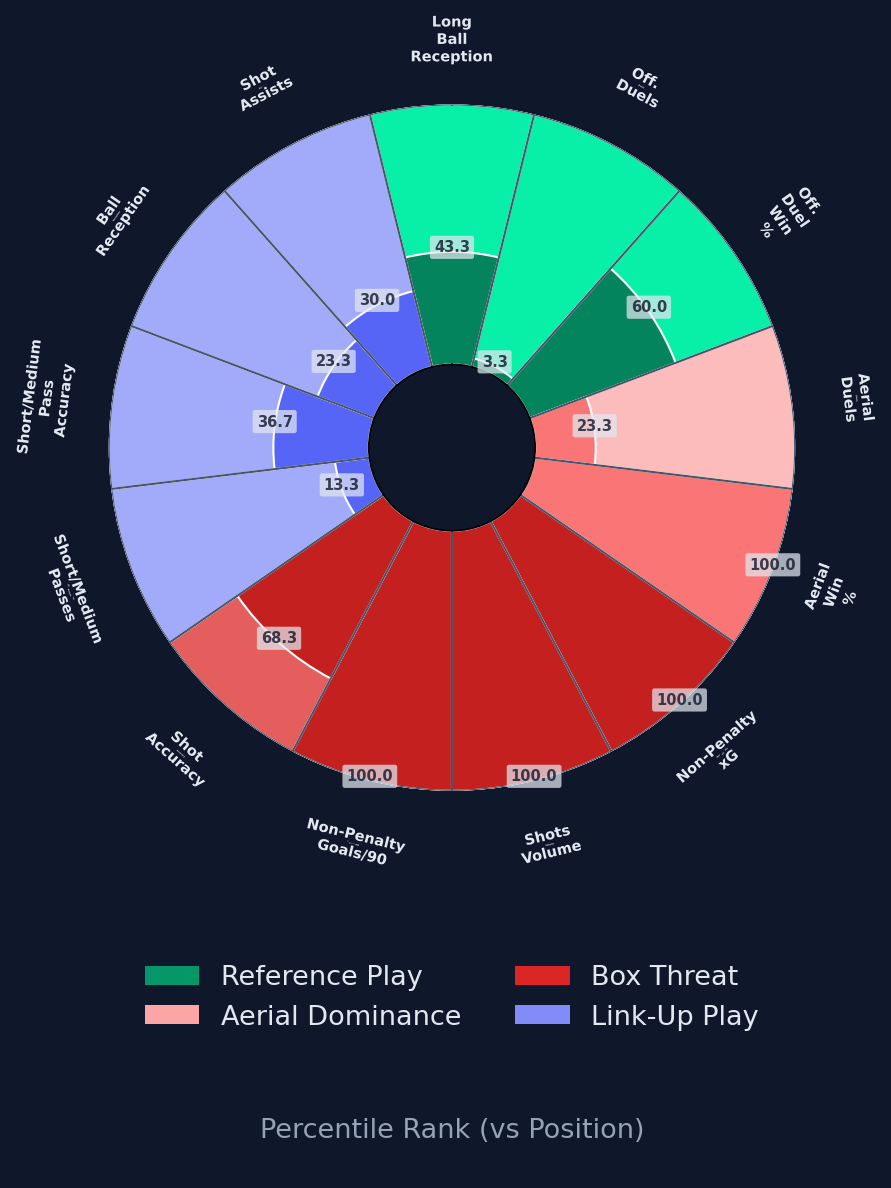

In [114]:
premier_league_25_26_df = df[df["league"] == "England Premier League 2025-26"].copy()
# premier_league_25_26_df[premier_league_25_26_df['team_within_selected_timeframe'] == "Arsenal"][['player', 'minutes_played']]
plot_player_profile(
    df=premier_league_25_26_df,
    player_names=["E. Haaland"],
    minimum_minutes_played=1000, 
    profile="target_man", 
    mode="position"
)

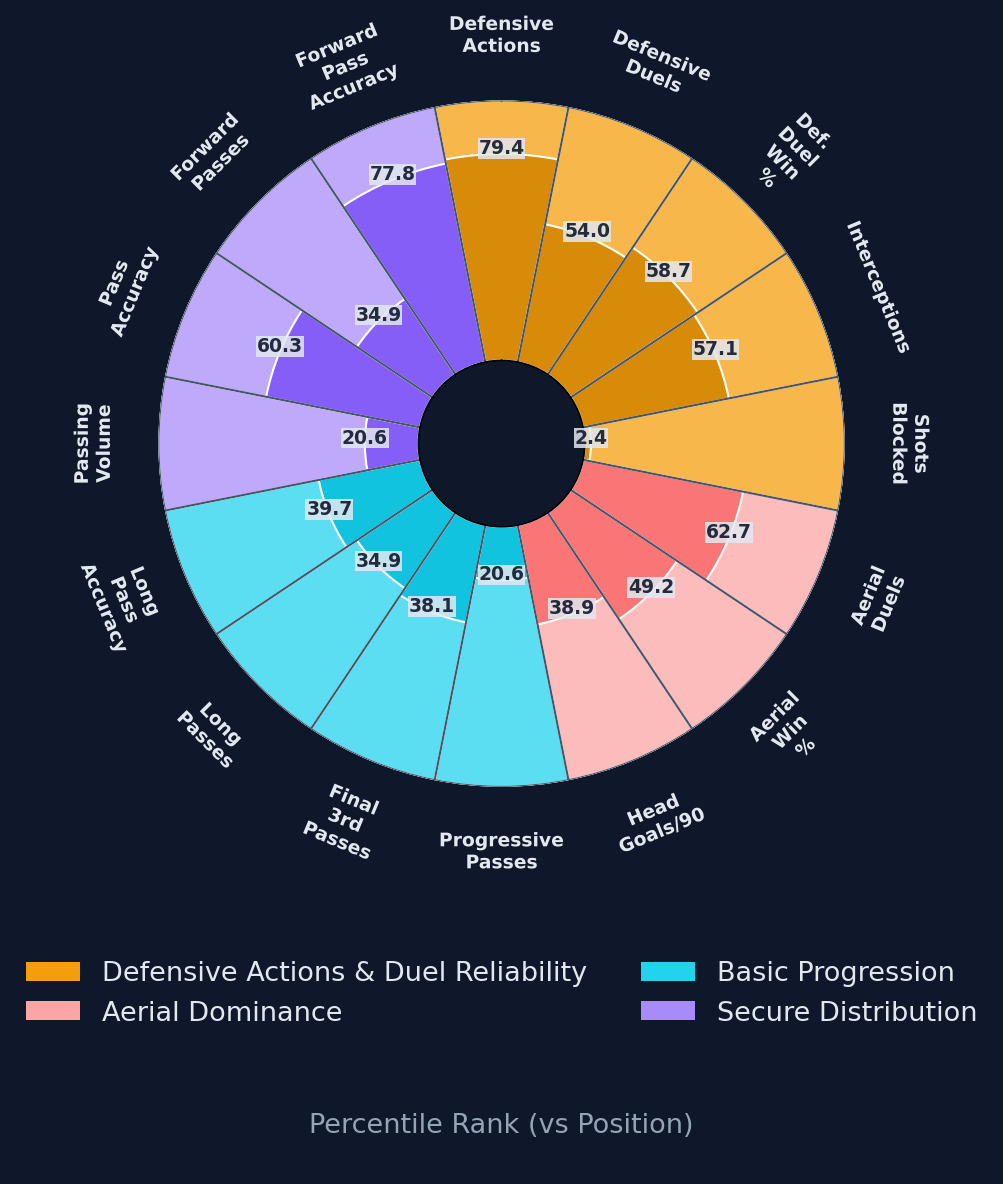

In [61]:
plot_player_profile(df=prva_liga_25_26_df, player_names=["D. Acimovic"], minimum_minutes_played=290, profile="aerially_dominant", mode="position")

In [16]:
prva_liga_25_26_df[prva_liga_25_26_df['player'] == "D. Acimovic"].to_dict()

{'unnamed:_0': {79499: 79499.0},
 'player': {79499: 'D. Acimovic'},
 'team': {79499: 'Jedinstvo Ub'},
 'team_within_selected_timeframe': {79499: 'Jedinstvo Ub'},
 'position': {79499: 'RCB'},
 'age': {79499: 21.0},
 'market_value': {79499: 0},
 'contract_expires': {79499: nan},
 'matches_played': {79499: 3},
 'minutes_played': {79499: 290},
 'goals': {79499: 0},
 'xg': {79499: 0.0},
 'assists': {79499: 0},
 'xa': {79499: 0.04},
 'duels_per_90': {79499: 12.1},
 'duels_won_%': {79499: 66.67},
 'birth_country': {79499: 'Serbia'},
 'passport_country': {79499: 'Serbia'},
 'foot': {79499: 'unknown'},
 'height': {79499: 0},
 'weight': {79499: 0},
 'on_loan': {79499: 'no'},
 'successful_defensive_actions_per_90': {79499: 9.0},
 'defensive_duels_per_90': {79499: 4.97},
 'defensive_duels_won_%': {79499: 68.75},
 'aerial_duels_per_90': {79499: 4.34},
 'aerial_duels_won_%': {79499: 57.14},
 'sliding_tackles_per_90': {79499: 0.93},
 'padj_sliding_tackles': {79499: 1.08},
 'shots_blocked_per_90': {79

In [12]:
# acimovic_df = df[df['player'] == "D. Acimovic"][[
#         "season", "league_base", "matches_played", "minutes_played",
#         "successful_defensive_actions_per_90",
#         "defensive_duels_per_90",
#         # "defensive_duels_won_%",
#         "interceptions_per_90",
#         # "shots_blocked_per_90",
#         "aerial_duels_per_90",
#         # "aerial_duels_won_%",
#         "progressive_passes_per_90",
#         # "passes_to_final_third_per_90",
#         # "long_passes_per_90",
#         # "accurate_long_passes_%",
#         # "passes_per_90",
#         # "accurate_passes_%",
#         # "forward_passes_per_90",
#         # "accurate_forward_passes_%",
        
# ]].copy()
# acimovic_df = acimovic_df.rename(columns={
#     "season": "Season",
#     "league_base": "League",
#     "matches_played": "Matches",
#     "minutes_played": "Minutes",
#     "successful_defensive_actions_per_90": "Def Actions/90",
#     "defensive_duels_per_90": "Def Duels/90",
#     "defensive_duels_won_%": "Def Duel Win %",
#     "aerial_duels_per_90": "Aerial Duel/90",
#     "aerial_duels_won_%": "Aerial Win %",
#     "interceptions_per_90": "Interceptions/90",
#     "shots_blocked_per_90": "Shots Blocked/90",
#     "progressive_passes_per_90": "Prog Passes/90",
#     "long_passes_per_90": "Long Passes/90",
#     "accurate_long_passes_%": "Acc Long Pass %",
#     "accurate_passes_%": "Pass Accuracy %",
# })
acimovic_df = df[df['player'] == "D. Acimovic"].copy()
acimovic_df["league_base"] = acimovic_df["league_base"].apply(
    lambda value: " ".join(str(value).split()[-2:])
)

In [31]:
print(len(acimovic_df.columns))
print(acimovic_df.columns.tolist())

14
['season', 'League', 'matches_played', 'Minutes', 'Def Actions/90', 'defensive_duels_per_90', 'Interceptions/90', 'shots_blocked_per_90', 'aerial_duels_per_90', 'Prog Passes/90', 'passes_to_final_third_per_90', 'Long Passes/90', 'passes_per_90', 'forward_passes_per_90']


In [1]:

def get_change_indicator(previous_value, current_value, tolerance=0.01):
    """
    Return change symbol and label comparing two numeric values.
    """
    if pd.isna(previous_value) or pd.isna(current_value):
        return "=", "no_data", 0.0

    difference = current_value - previous_value

    if abs(difference) <= tolerance:
        return "=", "stable", difference
    if difference > 0:
        return "+", "improved", difference
    return "-", "declined", difference

def build_player_development_table(player_df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    """
    Create a simple season-to-season comparison table for one player.
    Expects player_df to have one row per season, ordered by season.
    """
    player_df = player_df.sort_values("season").reset_index(drop=True)

    if len(player_df) < 2:
        raise ValueError("At least two seasons are required.")

    previous_row = player_df.iloc[-2]
    current_row = player_df.iloc[-1]

    development_rows = []

    for metric in metrics:
        previous_value = pd.to_numeric(previous_row.get(metric), errors="coerce")
        current_value = pd.to_numeric(current_row.get(metric), errors="coerce")

        indicator_symbol, change_label, difference = get_change_indicator(previous_value, current_value)

        development_rows.append({
            "Metric": metric,
            "Previous Season": round(previous_value, 2) if pd.notna(previous_value) else np.nan,
            "Current Season": round(current_value, 2) if pd.notna(current_value) else np.nan,
            "Change": round(difference, 2) if pd.notna(difference) else np.nan,
            "Indicator": indicator_symbol,
            "Status": change_label,
        })

    return pd.DataFrame(development_rows)

def format_development_table(development_df: pd.DataFrame, feature_labels: dict) -> pd.DataFrame:
    """
    Replace raw metric names with cleaner display labels.
    """
    display_df = development_df.copy()
    display_df["Metric"] = display_df["Metric"].map(lambda metric: feature_labels.get(metric, metric))
    return display_df

def plot_player_development_table(development_df: pd.DataFrame, save_path=None):
    """
    Plot a simple development table with change indicators.
    """
    background_color = "#0F172A"
    header_color = "#1E293B"
    row_color = "#111827"
    edge_color = "#475569"
    text_color = "#E2E8F0"
    body_text_color = "#CBD5E1"

    improved_color = "#34D399"
    declined_color = "#F87171"
    stable_color = "#94A3B8"

    fig, ax = plt.subplots(figsize=(9, max(2.8, 0.55 * len(development_df) + 1.4)))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)
    ax.axis("off")

    display_df = development_df[["Metric", "Previous Season", "Current Season", "Change", "Indicator"]].copy()

    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.32, 0.16, 0.16, 0.14, 0.10],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)

    indicator_column_index = list(display_df.columns).index("Indicator")

    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor(edge_color)
        cell.set_linewidth(1)

        if row == 0:
            cell.set_facecolor(header_color)
            cell.get_text().set_color(text_color)
            cell.get_text().set_weight("bold")
        else:
            cell.set_facecolor(row_color)
            cell.get_text().set_color(body_text_color)

            if col == indicator_column_index:
                indicator_value = display_df.iloc[row - 1, col]

                if indicator_value == "+":
                    cell.get_text().set_color(improved_color)
                    cell.get_text().set_weight("bold")
                elif indicator_value == "-":
                    cell.get_text().set_color(declined_color)
                    cell.get_text().set_weight("bold")
                else:
                    cell.get_text().set_color(stable_color)
                    cell.get_text().set_weight("bold")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )

    plt.show()

def plot_player_trend_lines(player_df: pd.DataFrame, metrics: list[str], feature_labels: dict, save_path=None):
    """
    Plot simple season-by-season trend lines for selected metrics.
    """
    background_color = "#0F172A"
    grid_color = "#475569"
    text_color = "#E2E8F0"

    fig, ax = plt.subplots(figsize=(10, 5.2))
    fig.patch.set_facecolor(background_color)
    ax.set_facecolor(background_color)

    player_df = player_df.sort_values("season").reset_index(drop=True)

    seasons = player_df["season"].astype(str).tolist()

    for metric in metrics:
        values = pd.to_numeric(player_df[metric], errors="coerce")
        ax.plot(
            seasons,
            values,
            marker="o",
            linewidth=2,
            label=feature_labels.get(metric, metric),
        )

    ax.set_title("Season Development", color=text_color, fontsize=14, weight="bold", pad=12)
    ax.tick_params(axis="x", colors=text_color)
    ax.tick_params(axis="y", colors=text_color)

    for spine in ax.spines.values():
        spine.set_color(grid_color)

    ax.grid(True, color=grid_color, alpha=0.35, linewidth=0.8)

    legend = ax.legend(frameon=False, fontsize=10, loc="best")
    for text in legend.get_texts():
        text.set_color(text_color)

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )

    plt.show()

development_metrics = [
    "successful_defensive_actions_per_90",
    "defensive_duels_won_%",
    "aerial_duels_won_%",
    "interceptions_per_90",
    "progressive_passes_per_90",
    "accurate_long_passes_%",
]

player_df = acimovic_df.sort_values("season")

development_df = build_player_development_table(
    player_df=player_df,
    metrics=development_metrics,
)

development_df = format_development_table(
    development_df=development_df,
    feature_labels=FEATURE_LABELS,
)

# plot_player_development_table(
#     development_df=development_df,
#     save_path="acimovic_development_table.png"
# )

# plot_player_trend_lines(
#     player_df=player_df,
#     metrics=[
#         "defensive_duels_won_%",
#         "aerial_duels_won_%",
#         "progressive_passes_per_90",
#     ],
#     feature_labels=FEATURE_LABELS,
#     save_path="acimovic_trend_lines.png"
# )

NameError: name 'pd' is not defined

In [76]:
comparison_positions = {
    "gk_comparison_positions": ["GK"],
    "cb_comparison_positions": ["CB", "CCB", "LCB", "RCB"],
    "fb_wb_comparison_positions": ["LB", "RB", "LWB", "RWB"],
    "dm_comparison_positions": ["DMF", "LDMF", "RDMF"],
    "cm_comparison_positions": ["LCMF", "RCMF", "CMF"],
    "am_comparison_positions": ["AMF", "LAMF", "RAMF"],
    "winger_comparison_positions": ["LW", "RW", "LWF", "RWF"],
    "cf_comparison_positions": ["CF"]
}

In [ ]:
def get_comparison_df(player_name: str, min_minutes_layed: int = 500) -> pd.DataFrame:

    PLAYER_NAME = player_name
    MIN_MINUTES_PLAYED = min_minutes_layed

    player_df = df[df["player"] == PLAYER_NAME].copy()

    if player_df.empty:
        raise ValueError(f"Player not found: {PLAYER_NAME}")

    player_league_season_contexts = (
        player_df[["league_base", "season"]]
        .drop_duplicates()
    )

    comparison_context_df = df.merge(
        player_league_season_contexts,
        on=["league_base", "season"],
        how="inner"
    )

    positions_to_compare = None
    position_group_name = None

    for group_name, group_positions in comparison_positions.items():
        if player_df["position"].isin(group_positions).any():
            position_group_name = group_name
            positions_to_compare = group_positions
            break

    if positions_to_compare is None:
        player_positions = player_df["position"].dropna().unique().tolist()
        raise ValueError(
            f"No comparison position group found for {PLAYER_NAME}. "
            f"Positions found: {player_positions}"
        )

    comparison_df = comparison_context_df[
        comparison_context_df["position"].isin(positions_to_compare)
        & (comparison_context_df["minutes_played"] > MIN_MINUTES_PLAYED)
    ].copy()

    print(f"Comparing {PLAYER_NAME} against {position_group_name}: {positions_to_compare}")
    print(f"League-season contexts used:")
    print(player_league_season_contexts)
    print(f"Comparison sample size: {len(comparison_df)}")

    return comparison_df

In [135]:
BRAND_COLORS = {
    "background_main": "#0F172A",
    "background_panel": "#1E293B",
    "text_main": "#E2E8F0",
    "text_body": "#CBD5E1",
    "text_muted": "#94A3B8",
    "border": "#475569",
}

CHART_COLORS = {
    "neutral": "#64748B",
    "highlight_old": "#38BDF8",
    "highlight_new": "#34D399",
    "arrow": "#F59E0B",

    "background_old_season": "#F43F5E",
    "background_new_season": "#FACC15",
}


def plot_player_development_scatter(
    df: pd.DataFrame,
    player_name: str,
    x_metric: str,
    y_metric: str,
    comparison_positions: list[str] | None = None,
    season_column: str = "season",
    player_column: str = "player",
    position_column: str = "position",
    save_path: str | None = None,
):
    """
    Plot a scatter graph showing all players in the comparison group,
    while highlighting a selected player's two seasons.
    """

    plot_df = df.copy()

    # # Filter comparison pool if desired
    # if comparison_positions:
    #     plot_df = plot_df[plot_df[position_column].isin(comparison_positions)].copy()

    # Ensure numeric values
    plot_df[x_metric] = pd.to_numeric(plot_df[x_metric], errors="coerce")
    plot_df[y_metric] = pd.to_numeric(plot_df[y_metric], errors="coerce")

    plot_df = plot_df.dropna(subset=[x_metric, y_metric])

    # Selected player's rows
    player_df = plot_df[plot_df[player_column] == player_name].copy()
    player_df = player_df.sort_values(season_column)

    if len(player_df) < 2:
        raise ValueError("The selected player needs at least two seasons for this chart.")

    player_previous = player_df.iloc[-2]
    player_current = player_df.iloc[-1]

    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor(BRAND_COLORS["background_main"])
    ax.set_facecolor(BRAND_COLORS["background_main"])

    sizes = plot_df["minutes_played"].fillna(0) / 8
    sizes = sizes.clip(lower=30, upper=300)

    background_color_map = {
        "2024-25": CHART_COLORS["background_old_season"],
        "2025": CHART_COLORS["background_old_season"],

        "2025-26": CHART_COLORS["background_new_season"],
        "2026": CHART_COLORS["background_new_season"],
    }

    for season, group_df in plot_df.groupby("season"):
        group_sizes = group_df["minutes_played"].fillna(0) / 8
        group_sizes = group_sizes.clip(lower=30, upper=300)
        label = group_df["league"].iloc[0]

        ax.scatter(
            group_df[x_metric],
            group_df[y_metric],
            s=group_sizes,
            alpha=0.28,
            color=background_color_map.get(season, CHART_COLORS["neutral"]),
            edgecolors="none",
            label=label,
            zorder=1,
        )

    previous_size = max(80, player_previous["minutes_played"] / 6)
    current_size = max(80, player_current["minutes_played"] / 6)

    # Highlight player's previous season
    ax.scatter(
        player_previous[x_metric],
        player_previous[y_metric],
        s=previous_size,
        color=CHART_COLORS["highlight_old"],
        edgecolors=BRAND_COLORS["text_main"],
        linewidths=1.2,
        zorder=5,
        label=f"{player_name} {player_previous[season_column]}",
    )

    # Highlight player's current season
    ax.scatter(
        player_current[x_metric],
        player_current[y_metric],
        s=current_size,
        color=CHART_COLORS["highlight_new"],
        edgecolors=BRAND_COLORS["text_main"],
        linewidths=1.2,
        zorder=6,
        label=f"{player_name} {player_current[season_column]}",
    )

    # Arrow showing development
    ax.annotate(
        "",
        xy=(player_current[x_metric], player_current[y_metric]),
        xytext=(player_previous[x_metric], player_previous[y_metric]),
        arrowprops=dict(
            arrowstyle="->",
            color=CHART_COLORS["arrow"],
            lw=2.2,
        ),
        zorder=4,
    )

    # Labels for the player's two seasons
    ax.text(
        player_previous[x_metric],
        player_previous[y_metric] + 0.6,
        f"{player_previous[season_column]}",
        color=CHART_COLORS["highlight_old"],
        fontsize=11,
        weight="bold",
        ha="center",
    )

    ax.text(
        player_current[x_metric],
        player_current[y_metric] + 0.6,
        f"{player_current[season_column]}",
        color=CHART_COLORS["highlight_new"],
        fontsize=11,
        weight="bold",
        ha="center",
    )

    # Axis labels
    ax.set_xlabel(FEATURE_LABELS.get(x_metric, x_metric), color=BRAND_COLORS["text_main"], fontsize=12, labelpad=10)
    ax.set_ylabel(FEATURE_LABELS.get(y_metric, y_metric), color=BRAND_COLORS["text_main"], fontsize=12, labelpad=10)
   
    # Title
    ax.set_title(
        f"{player_name} | Development Scatter",
        color=BRAND_COLORS["text_main"],
        fontsize=16,
        weight="bold",
        pad=14,
    )

    # Grid and spines
    ax.grid(True, color=BRAND_COLORS["border"], alpha=0.3, linewidth=0.8)
    for spine in ax.spines.values():
        spine.set_color(BRAND_COLORS["border"])

    ax.tick_params(colors=BRAND_COLORS["text_body"])

    # Legend
    legend = ax.legend(frameon=False, fontsize=11, loc="best")
    for text in legend.get_texts():
        text.set_color(BRAND_COLORS["text_body"])

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
            facecolor=fig.get_facecolor(),
        )

    plt.show()

Comparing M. Thiaw against cb_comparison_positions: ['CB', 'CCB', 'LCB', 'RCB']
League-season contexts used:
                  league_base   season
37441  England Premier League  2025-26
51538           Italy Serie A  2024-25
Comparison sample size: 187


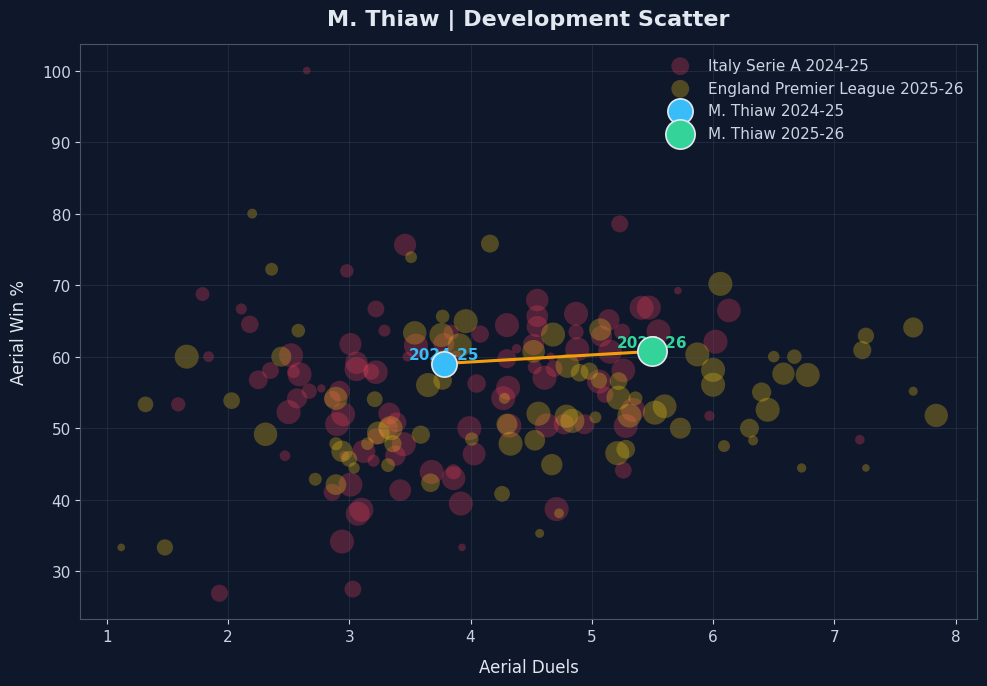

In [156]:
# Aerial Dominance
x_metric = "aerial_duels_per_90"
y_metric = "aerial_duels_won_%"

# Aerial Dominance + Progression
# x_metric = "progressive_passes_per_90"
# y_metric = "aerial_duels_won_%"

# Aerial Dominance vs Carrying Progression
# x_metric = "aerial_duels_won_%"
# y_metric = "progressive_runs_per_90"

# Passing vs Carrying Progression
# x_metric = "progressive_passes_per_90"
# y_metric = "progressive_runs_per_90"

PLAYER_NAME = "M. Thiaw"
MIN_MINUTES_PLAYED = 200
position_to_compare_df = get_comparison_df(player_name=PLAYER_NAME, min_minutes_layed=MIN_MINUTES_PLAYED)

save_path = "_".join(PLAYER_NAME.lower().replace(".", "").split(" "))
plot_player_development_scatter(
    df=position_to_compare_df,
    player_name=PLAYER_NAME,
    x_metric=x_metric,
    y_metric=y_metric,
    comparison_positions=comparison_positions,
    save_path=f"{save_path}_development_scatter.png",
)

In [ ]:
# ATTACKING FULL-BACK
# 1. Main delivery profile
x_metric = "crosses_per_90"
y_metric = "accurate_crosses_%"

# # 2. Delivery into chance value
# x_metric = "crosses_per_90"
# y_metric = "xa_per_90"

# # 3. Advanced delivery
# x_metric = "deep_completed_crosses_per_90"
# y_metric = "xa_per_90"

# # 4. Movement into delivery
# x_metric = "progressive_runs_per_90"
# y_metric = "crosses_per_90"

# # 5. Progression style
# x_metric = "progressive_passes_per_90"
# y_metric = "progressive_runs_per_90"

# # 6. 1v1 wide threat
# x_metric = "dribbles_per_90"
# y_metric = "successful_dribbles_%"